# 1. Import Necessary Libraries

In [4]:
# 1. IMPORT NECESSARY LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

This cell imports all the necessary libraries for the project. It includes `pandas` for data manipulation, `numpy` for numerical operations, `matplotlib.pyplot` and `seaborn` for data visualization, and several modules from `sklearn` for machine learning tasks such as model selection, ensemble methods, imputation, preprocessing, pipeline creation, and evaluation metrics.

# 2. Set Plot Style

In [5]:
# Set plot style for better visuals
sns.set_theme(style="whitegrid")

This cell sets the visual style for all plots generated using `seaborn`. `sns.set_theme(style="whitegrid")` applies a white background with a grid, which is a common and clean aesthetic for data visualizations.

# 3. Define Features and Target

In [6]:
# 3. DEFINE FEATURES AND TARGET
# We are predicting 'GDP'
target = 'GDP'

# Load the dataset
df = pd.read_csv('world_economics.csv')

# Numeric features to use
numeric_features = [
    'Population', 'area', 'Interest Rate',
    'Inflation Rate', 'Jobless Rate', 'Debt/GDP', 'Gov. Budget'
]

# Categorical features to use
categorical_features = ['region', 'subregion']

# Filter dataset to only include our features and target
X = df[numeric_features + categorical_features]
y = df[target]

This cell defines the target variable ('GDP') and loads the `world_economics.csv` dataset into a pandas DataFrame. It also specifies the lists of numeric and categorical features that will be used for model training, and then filters the dataset to include only these features and the target.

# 4. Build the Preprocessing Pipeline

In [7]:
# 4. BUILD THE PREPROCESSING PIPELINE
# Handle missing numeric values by replacing them with the median
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Handle categorical text (like "Asia") by turning them into numbers, filling missing with "Unknown"
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine both steps into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

This cell constructs the preprocessing pipeline for both numeric and categorical features. For numeric features, it uses `SimpleImputer` with a 'median' strategy to handle missing values. For categorical features, it uses `SimpleImputer` with 'Unknown' as a constant fill value, followed by `OneHotEncoder` to convert categorical text into numerical representations suitable for machine learning models. These transformers are then combined into a `ColumnTransformer`.

# 5. Create the Full Model Pipeline

In [8]:
#5. CREATE THE FULL MODEL PIPELINE
# We attach the Random Forest Regressor to the end of the preprocessing steps
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])


This cell creates the full machine learning pipeline. It combines the `preprocessor` defined earlier with a `RandomForestRegressor`. The random forest model is configured with 100 estimators and a `random_state` for reproducibility.

# 6. Split Data, Train, and Evaluate Model

In [9]:
# 6. SPLIT THE DATA (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. TRAIN THE MODEL
print("Training the Random Forest model...")
model.fit(X_train, y_train)

# 8. EVALUATE THE MODEL
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("-" * 30)
print("MODEL PERFORMANCE:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2) Score:      {r2:.2f}")
print("-" * 30)

Training the Random Forest model...
------------------------------
MODEL PERFORMANCE:
Mean Absolute Error (MAE): 394.96
R-squared (R2) Score:      0.89
------------------------------


This cell first splits the data into training (80%) and testing (20%) sets using `train_test_split`. Then, it trains the `model` pipeline on the training data. Finally, it evaluates the trained model's performance on the test set by calculating the Mean Absolute Error (MAE) and R-squared (R2) score, and prints these metrics.

# 7. Extract Feature Importances

In [10]:
# 9. EXTRACT & PLOT FEATURE IMPORTANCES
# Get the trained random forest model from the pipeline
rf_model = model.named_steps['regressor']
importances = rf_model.feature_importances_

# Get the names of the features after One-Hot Encoding
cat_encoder = model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_feature_names)

# Create a DataFrame for importances
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10) # Top 10


This cell extracts and prepares feature importances from the trained `RandomForestRegressor`. It retrieves the `feature_importances_` from the regressor and maps them back to their original feature names, including the one-hot encoded categorical features. The top 10 most important features are then stored in a DataFrame.

# 8. Visualize Feature Importance

/tmp/ipykernel_3091/1962310554.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


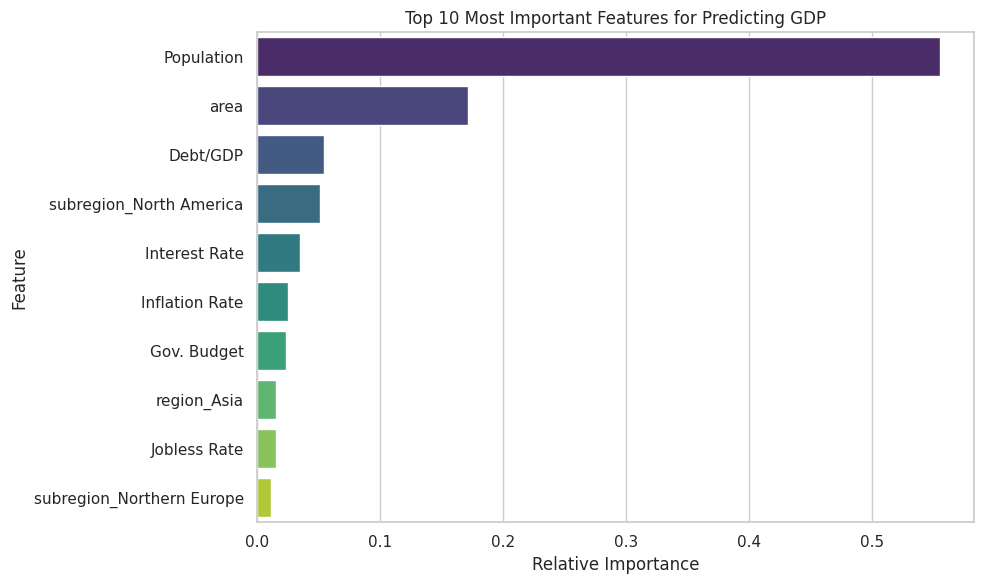

In [11]:
# Plot 1: Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Top 10 Most Important Features for Predicting GDP')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

This cell generates a bar plot visualizing the top 10 most important features for predicting GDP, based on the feature importances extracted in the previous step. It uses `seaborn.barplot` to display the relative importance of each feature.

# 9. Visualize Actual vs. Predicted GDP

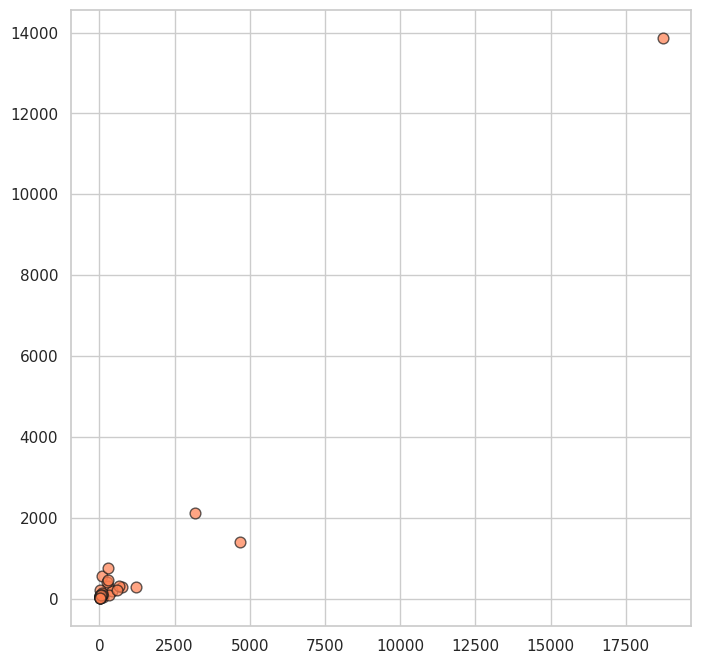

In [12]:
# Plot 2: Actual vs Predicted Scatter Plot
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.7, color='#FF7F50', edgecolor='k', s=60)

This cell initializes a scatter plot to compare the actual GDP values from the test set against the GDP values predicted by the model. Each point represents a data instance, with its actual GDP on the x-axis and predicted GDP on the y-axis.

# 10. Save Predictions to CSV

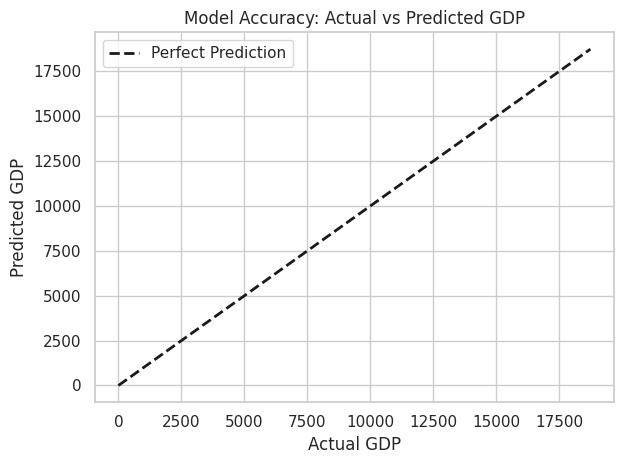

In [13]:
# Draw the perfect prediction diagonal line
max_val = max(y_test.max(), y_pred.max())
min_val = min(y_test.min(), y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual GDP')
plt.ylabel('Predicted GDP')
plt.title('Model Accuracy: Actual vs Predicted GDP')
plt.legend()
plt.tight_layout()
plt.show()

This cell completes the 'Actual vs Predicted' scatter plot. It adds a diagonal dashed line representing 'perfect prediction' (where actual equals predicted). It also sets the x and y axis labels, the plot title, and displays a legend, providing a visual assessment of the model's accuracy.

# 11. Conclusion

In [14]:
# 10. SAVE PREDICTIONS TO CSV
results = pd.DataFrame({
    'Country_Index': y_test.index,
    'Actual_GDP': y_test.values,
    'Predicted_GDP': np.round(y_pred, 2)
})
results.to_csv('gdp_predictions_results.csv', index=False)
print("\nPredictions successfully saved to 'gdp_predictions_results.csv'")


Predictions successfully saved to 'gdp_predictions_results.csv'


This final cell saves the model's predictions to a CSV file named `gdp_predictions_results.csv`. It creates a DataFrame containing the original country index, actual GDP values from the test set, and the corresponding predicted GDP values (rounded to two decimal places). This allows for easy inspection and further analysis of the model's output.